<a href="https://colab.research.google.com/github/ahmere-s/predicting_home_prices/blob/main/predicting_home_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sframe

ERROR: Could not find a version that satisfies the requirement sframe (from versions: none)
ERROR: No matching distribution found for sframe


In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


In [ ]:
!conda run -n sf pip install turicreate

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 19.9 MB/s

In [ ]:
# About to utilize turicreate to read SFrame data, write it to the disk as a csv file, and return back to the normal kernel using pandas on the csv.

In [ ]:
from google.colab import files
uploaded = files.upload()     #triggers file picker

Saving dir_archive.ini to dir_archive.ini
Saving m_1ce96d9d245ca490.0000 to m_1ce96d9d245ca490.0000
Saving m_1ce96d9d245ca490.frame_idx to m_1ce96d9d245ca490.frame_idx
Saving m_1ce96d9d245ca490.sidx to m_1ce96d9d245ca490.sidx
Saving objects.bin to objects.bin


In [ ]:
import os, shutil
os.makedirs('/content/home_data.sframe', exist_ok=True)
for filename in uploaded.keys():
  shutil.move(f'/content/{filename}', f'/content/home_data.sframe/{filename}')

print(os.listdir('/content/home_data.sframe'))

['dir_archive.ini', 'm_1ce96d9d245ca490.0000', 'm_1ce96d9d245ca490.frame_idx', 'm_1ce96d9d245ca490.sidx', 'objects.bin']


In [ ]:
script = """
import turicreate as tc
sf = tc.SFrame('/content/home_data.sframe')
sf.export_csv('/content/output.csv')

print("Shape: ", sf.shape)
"""

with open('run_sframe.py', 'w') as fi:
  fi.write(script)

In [ ]:
!conda run -n sf python /content/run_sframe.py

Traceback (most recent call last):
  File "/content/run_sframe.py", line 6, in <module>
    print("Shape: ", sf.shape())
TypeError: 'tuple' object is not callable

ERROR conda.cli.main_run:execute(127): `conda run python /content/run_sframe.py` failed. (See above for error)


In [ ]:
# CSV already created. Can update sf.shape() to sf.shape (a property instead of tuple)

In [ ]:
!conda run -n sf python /content/run_sframe.py

Shape:  (21613, 21)



In [ ]:
import pandas as pa

In [ ]:
df = pa.read_csv('/content/output.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [1]:
%matplotlib inline
import matplotlib.pyplot as mpl

In [2]:
df.plot.scatter(x="sqft_living", y="price", alpha=0.3)
mpl.title("Price vs Sqft Living")
mpl.xlabel("Sqft Living")
mpl.ylabel("Price")
mpl.show()

NameError: name 'df' is not defined

In [3]:
!conda --version

conda 25.11.0


In [4]:
!conda run -n sf pip install turicreate


EnvironmentLocationNotFound: Not a conda environment: /usr/local/envs/sf



In [8]:
!conda run -n sf python /content/run_sframe.py

Shape:  (21613, 21)



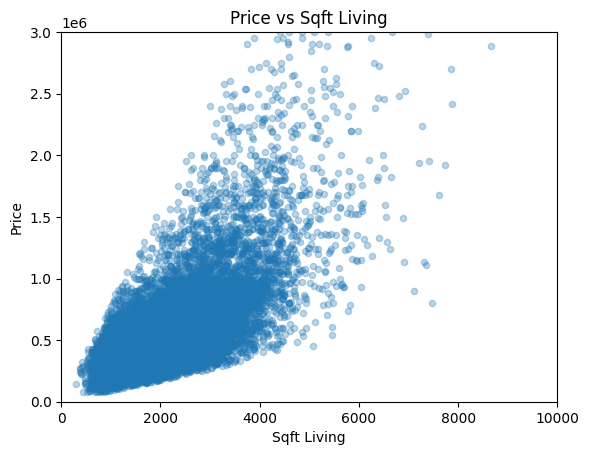

In [10]:
import pandas as pd
df = pd.read_csv('/content/output.csv')
%matplotlib inline
import matplotlib.pyplot as mpl
df.plot.scatter(x="sqft_living", y="price", alpha=0.3)
mpl.title("Price vs Sqft Living")
mpl.xlabel("Sqft Living")
mpl.ylabel("Price")
mpl.xlim(0, 10000)
mpl.ylim(0, 3000000)
mpl.show()